## khảo sát dữ liệu

### Import các thư viện cần thiết

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Lấy code trong file data/data.csv

In [3]:
df=pd.read_csv('data/AirQuality.csv')
print(df.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  PT08.S2(NMHC)  NOx(GT)  \
0  3/10/2004  18:00:00     2.6       1360.0     150.0         1046.0    166.0   
1  3/10/2004  19:00:00     2.0       1292.0     112.0          955.0    103.0   
2  3/10/2004  20:00:00     2.2       1402.0      88.0          939.0    131.0   
3  3/10/2004  21:00:00     2.2       1376.0      80.0          948.0    172.0   
4  3/10/2004  22:00:00     1.6       1272.0      51.0          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  \
0        1056.0    113.0        1692.0       1268.0  13.6  48.9  0.7578   
1        1174.0     92.0        1559.0        972.0  13.3  47.7  0.7255   
2        1140.0    114.0        1555.0       1074.0  11.9  54.0  0.7502   
3        1092.0    122.0        1584.0       1203.0  11.0  60.0  0.7867   
4        1205.0    116.0        1490.0       1110.0  11.2  59.6  0.7888   

   C6H6(GT)  
0      11.9  
1       9.4  
2       9.0  
3     

### Kiểm tra trùng lặp

In [4]:
duplicates = df.duplicated().sum()
print(f"Số lượng dòng trùng lắp: {duplicates}")
df.drop_duplicates(inplace=True)

Số lượng dòng trùng lắp: 0


### Xem thông tin của data

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        7718 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        7715 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
 14  C6H6(GT)       8991 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB
None


### Thống kê mô tả

In [6]:
print(df.describe())

            CO(GT)  PT08.S1(CO)     NMHC(GT)  PT08.S2(NMHC)      NOx(GT)  \
count  7674.000000  8991.000000   914.000000    8991.000000  7718.000000   
mean      2.152750  1099.833166   218.811816     939.153376   246.896735   
std       1.453252   217.080037   204.459921     266.831429   212.979168   
min       0.100000   647.000000     7.000000     383.000000     2.000000   
25%       1.100000   937.000000    67.000000     734.500000    98.000000   
50%       1.800000  1063.000000   150.000000     909.000000   180.000000   
75%       2.900000  1231.000000   297.000000    1116.000000   326.000000   
max      11.900000  2040.000000  1189.000000    2214.000000  1479.000000   

       PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)            T  \
count   8991.000000  7715.000000   8991.000000  8991.000000  8991.000000   
mean     835.493605   113.091251   1456.264598  1022.906128    18.317829   
std      256.817320    48.370108    346.206794   398.484288     8.832116   
min      32

### Phân phối histogram và boxplot cho từng thuộc tính của data

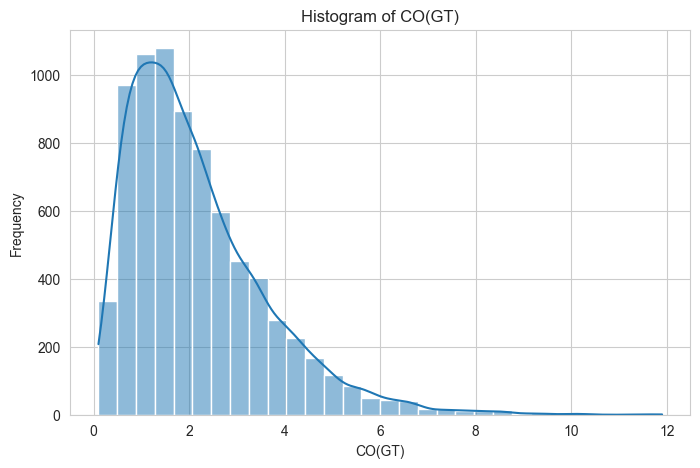

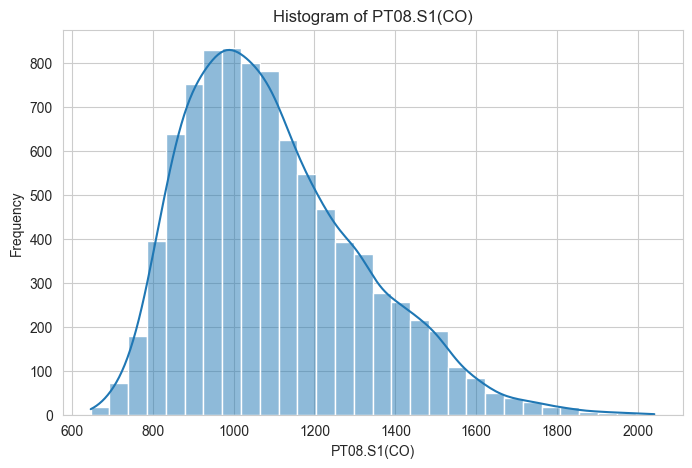

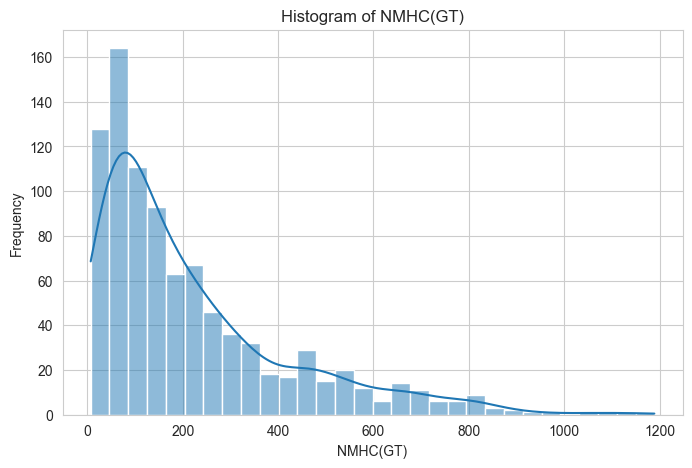

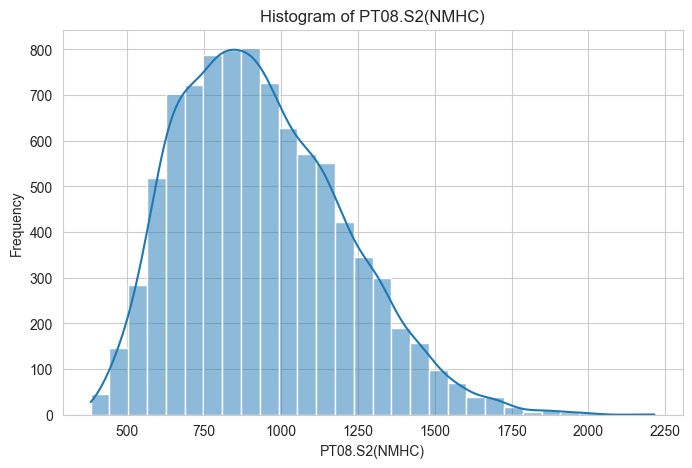

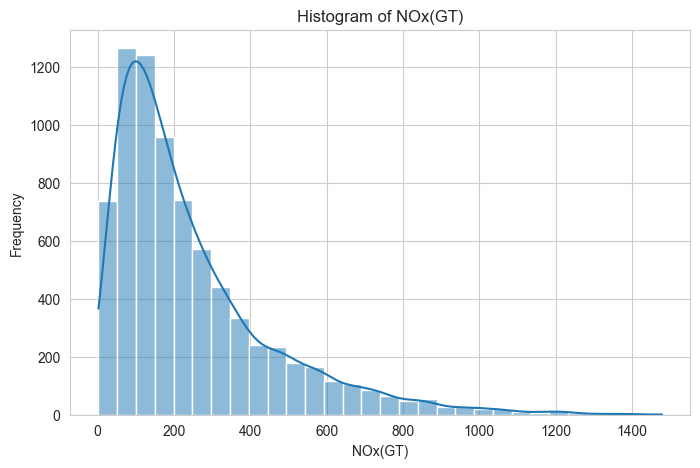

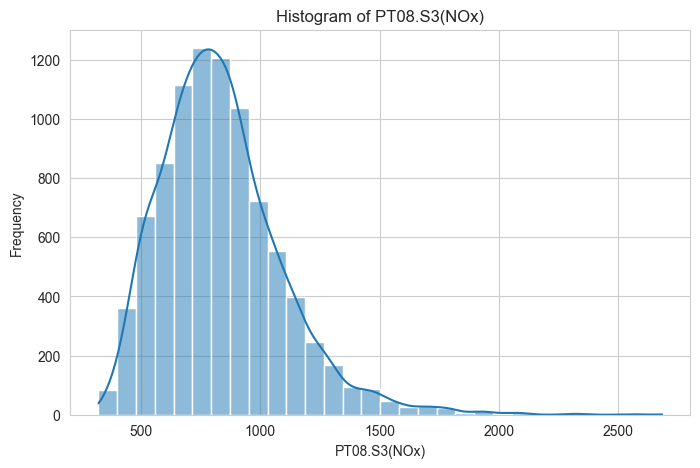

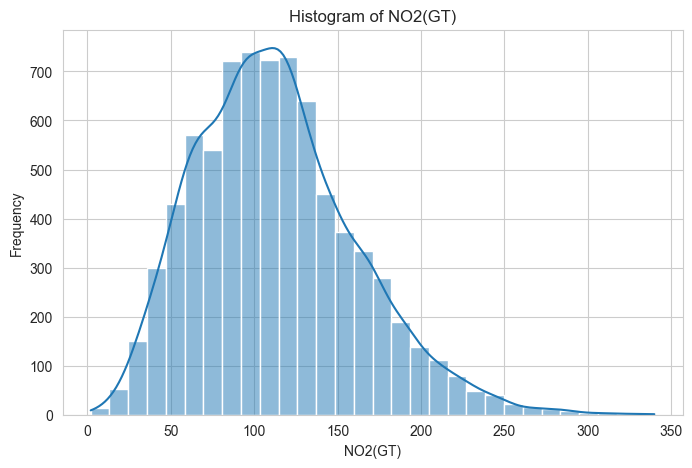

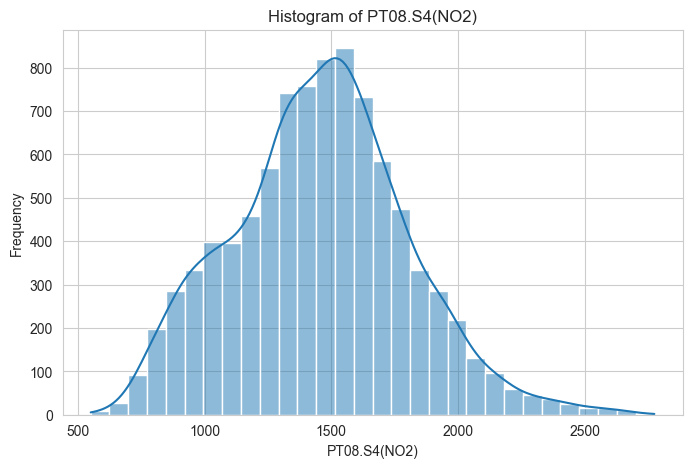

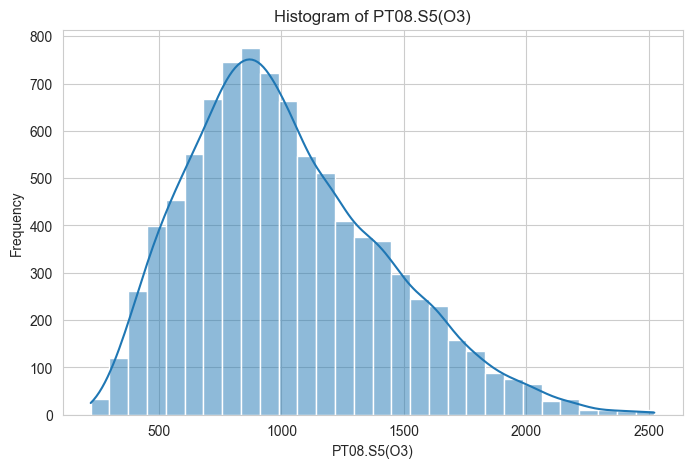

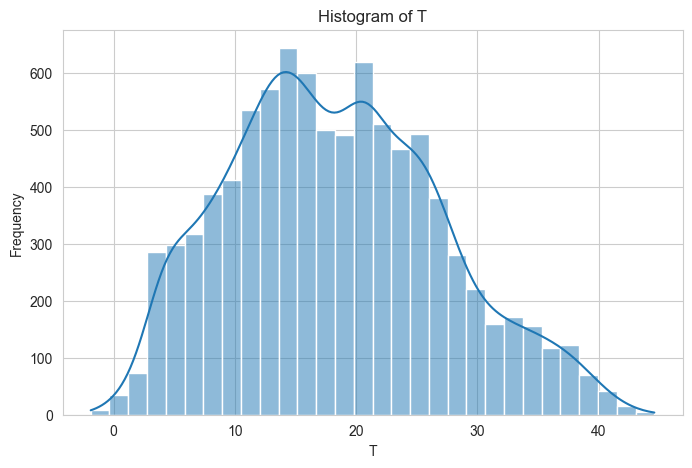

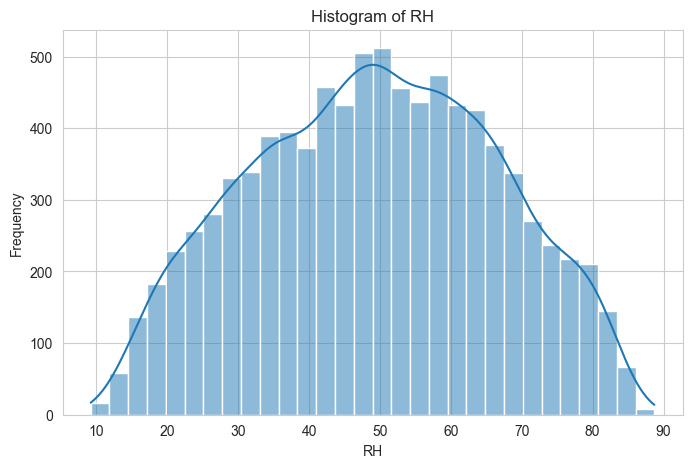

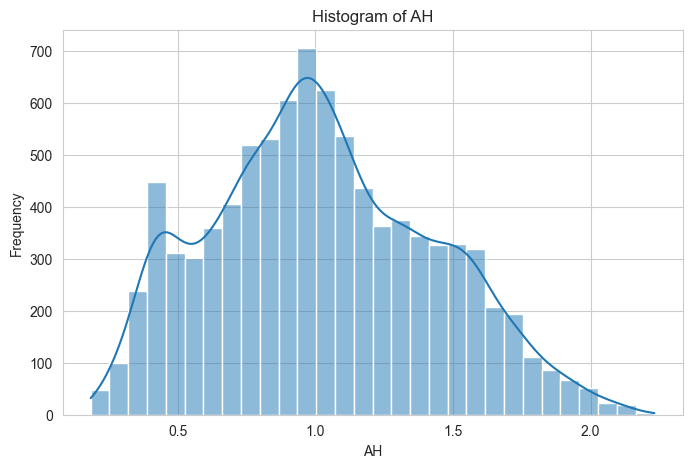

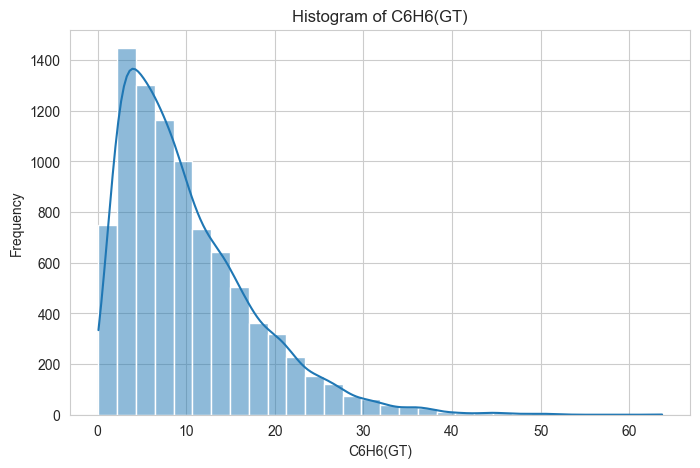

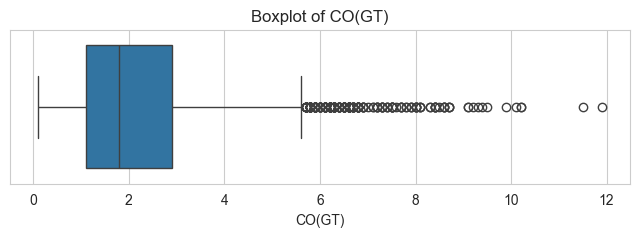

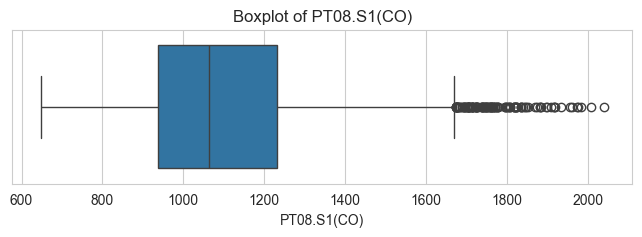

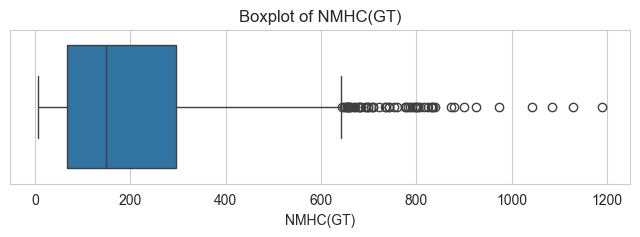

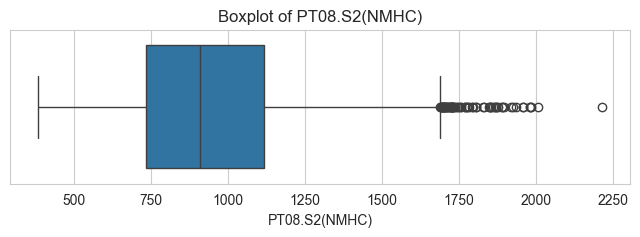

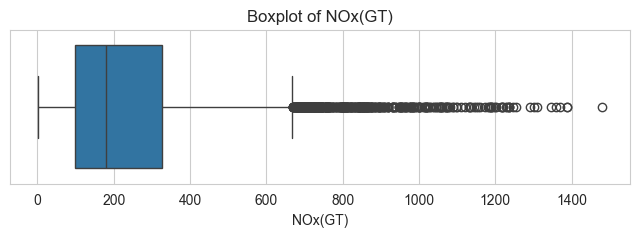

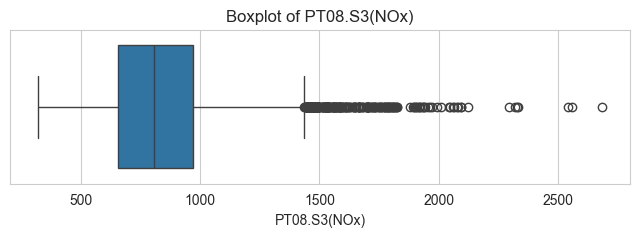

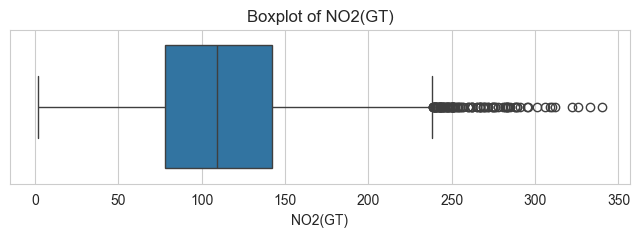

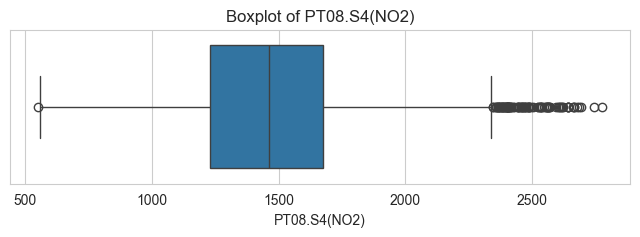

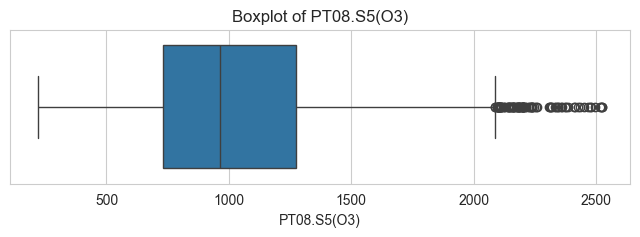

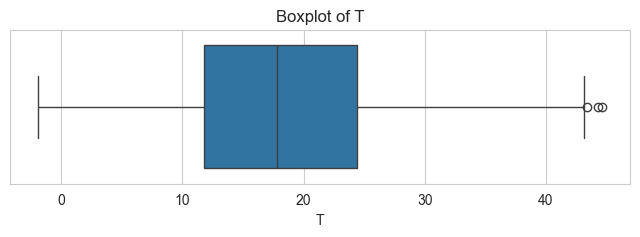

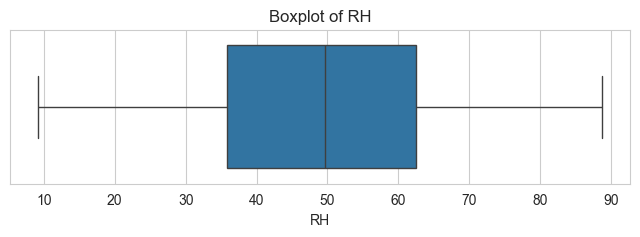

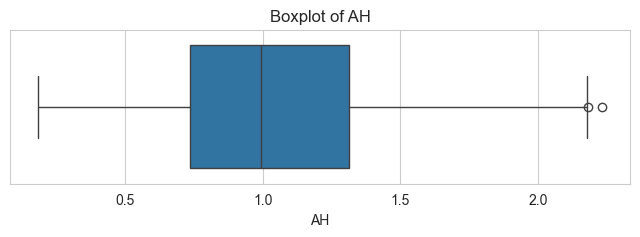

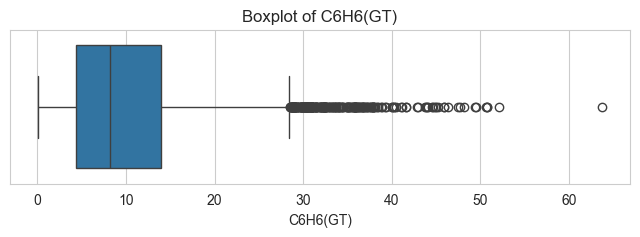

In [7]:
# lấy tất cả cột dạng số
numeric_columns = df.select_dtypes(include=['number']).columns

# style đẹp hơn
sns.set_style("whitegrid")

# =========================
# HISTPLOT
# =========================
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True
    )
    
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

# =========================
# BOXPLOT
# =========================
for col in numeric_columns:
    plt.figure(figsize=(8, 2))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

### Trích xuất đặc trưng thời gian và xử lí dữ liệu ở DataFrame tạm để vẽ heatmap

In [8]:
df_temp=df.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp['Month'] = df_temp['Date'].dt.month
df_temp['DayOfWeek'] = df_temp['Date'].dt.dayofweek # 0: Thứ 2, 6: Chủ nhật

# Xử lý Time
df_temp['Hour'] = pd.to_datetime(df_temp['Time'], format='%H:%M:%S').dt.hour

# Loại bỏ cột gốc sau khi đã trích xuất
df_numerics = df_temp.drop(columns=['Date', 'Time'])

### Heatmap tương quan giữa các thành phần

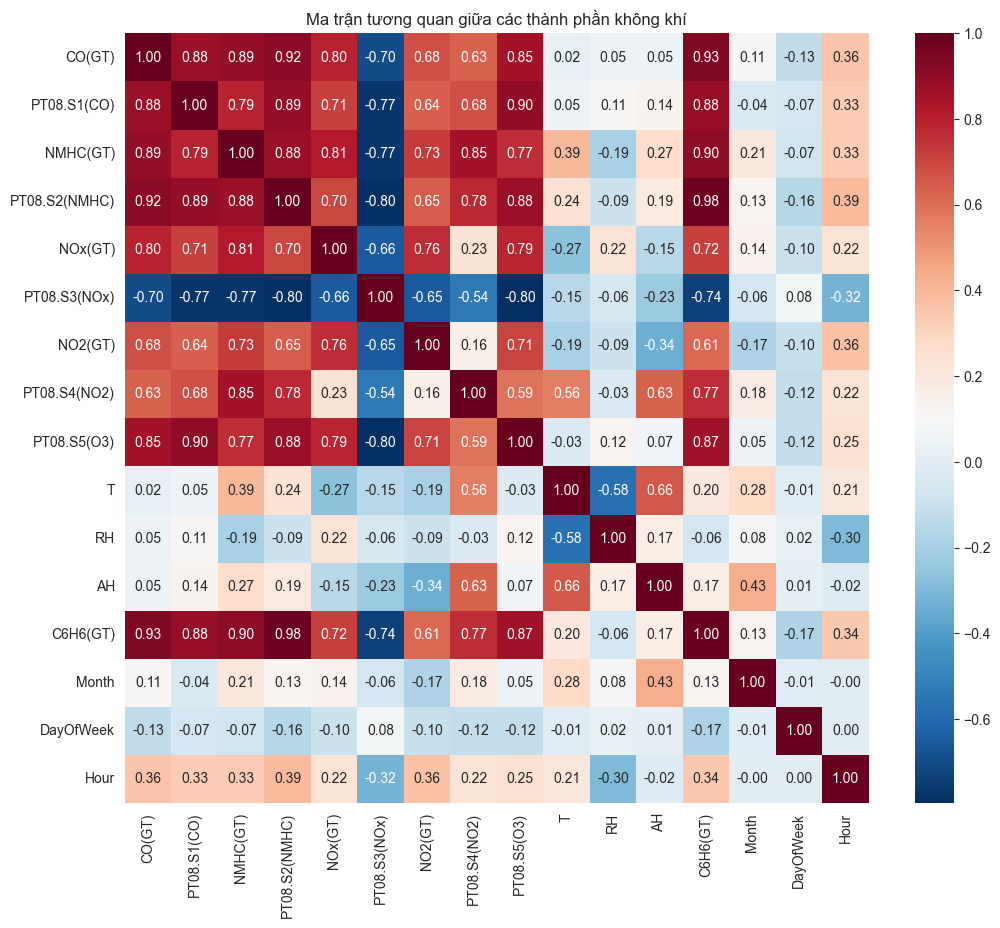

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_numerics.corr(), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Ma trận tương quan giữa các thành phần không khí')
plt.show()

### Missing values

In [10]:
missing_rate=df.isnull().mean()*100
print(missing_rate)

Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
C6H6(GT)          3.911510
dtype: float64


### Khảo sát ourliers của mỗi cột (Ở đây chỉ thực hiện khảo sát còn lọc sẽ thực hiện ở data_pipline)

In [11]:
import pandas as pd

numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:

    temp = df[col].dropna()

    Q1 = temp.quantile(0.25)
    Q3 = temp.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = temp[
        (temp < lower) |
        (temp > upper)
    ]

    print("=" * 50)
    print(f"Column: {col}")
    print(f"Outliers: {len(outliers)}")
    print(f"Outlier Rate: {len(outliers)/len(temp)*100:.2f}%")

Column: CO(GT)
Outliers: 215
Outlier Rate: 2.80%
Column: PT08.S1(CO)
Outliers: 118
Outlier Rate: 1.31%
Column: NMHC(GT)
Outliers: 55
Outlier Rate: 6.02%
Column: PT08.S2(NMHC)
Outliers: 65
Outlier Rate: 0.72%
Column: NOx(GT)
Outliers: 435
Outlier Rate: 5.64%
Column: PT08.S3(NOx)
Outliers: 241
Outlier Rate: 2.68%
Column: NO2(GT)
Outliers: 107
Outlier Rate: 1.39%
Column: PT08.S4(NO2)
Outliers: 97
Outlier Rate: 1.08%
Column: PT08.S5(O3)
Outliers: 93
Outlier Rate: 1.03%
Column: T
Outliers: 3
Outlier Rate: 0.03%
Column: RH
Outliers: 0
Outlier Rate: 0.00%
Column: AH
Outliers: 2
Outlier Rate: 0.02%
Column: C6H6(GT)
Outliers: 228
Outlier Rate: 2.54%


### Z-score Outlier Detection

Bên cạnh phương pháp IQR, ta sử dụng thêm **Z-score** (từ `scipy.stats.zscore`) để phát hiện outliers.
Một điểm dữ liệu được coi là outlier nếu `|z-score| > 3` (tức cách trung bình hơn 3 độ lệch chuẩn).

Sau đó ta so sánh kết quả giữa hai phương pháp để thấy sự khác biệt.

In [12]:
from scipy import stats
import pandas as pd
import numpy as np

# --- Z-score Outlier Detection ---
numeric_columns = df.select_dtypes(include=['number']).columns
zscore_threshold = 3  # Ngưỡng chuẩn: |z| > 3 được coi là outlier

# Bảng so sánh IQR vs Z-score
comparison_data = []

for col in numeric_columns:
    temp = df[col].dropna()
    
    # --- IQR Method ---
    Q1 = temp.quantile(0.25)
    Q3 = temp.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    n_outliers_iqr = len(temp[(temp < lower_iqr) | (temp > upper_iqr)])
    
    # --- Z-score Method ---
    z_scores = stats.zscore(temp)
    n_outliers_zscore = len(temp[np.abs(z_scores) > zscore_threshold])
    
    comparison_data.append({
        'Column': col,
        'Total': len(temp),
        'IQR_Outliers': n_outliers_iqr,
        'IQR_Rate(%)': round(n_outliers_iqr / len(temp) * 100, 2),
        'Zscore_Outliers': n_outliers_zscore,
        'Zscore_Rate(%)': round(n_outliers_zscore / len(temp) * 100, 2),
    })

comparison_df = pd.DataFrame(comparison_data)
print('=' * 80)
print('SO SÁNH OUTLIER DETECTION: IQR vs Z-score (|z| > 3)')
print('=' * 80)
print(comparison_df.to_string(index=False))
print()
print('Nhận xét:')
print('- IQR thường phát hiện NHIỀU outliers hơn Z-score vì IQR dựa trên khoảng tứ phân vị,')
print('  nhạy cảm hơn với phân phối lệch (skewed distributions) của dữ liệu cảm biến.')
print('- Z-score chỉ phát hiện các giá trị CỰC KỲ bất thường (> 3 std),')
print('  phù hợp hơn khi dữ liệu có phân phối gần chuẩn (normal distribution).')
print('- Với dữ liệu Air Quality, nên ƯU TIÊN kết quả IQR vì phân phối dữ liệu lệch mạnh.')

SO SÁNH OUTLIER DETECTION: IQR vs Z-score (|z| > 3)
       Column  Total  IQR_Outliers  IQR_Rate(%)  Zscore_Outliers  Zscore_Rate(%)
       CO(GT)   7674           215         2.80              102            1.33
  PT08.S1(CO)   8991           118         1.31               60            0.67
     NMHC(GT)    914            55         6.02               12            1.31
PT08.S2(NMHC)   8991            65         0.72               37            0.41
      NOx(GT)   7718           435         5.64              138            1.79
 PT08.S3(NOx)   8991           241         2.68              109            1.21
      NO2(GT)   7715           107         1.39               48            0.62
 PT08.S4(NO2)   8991            97         1.08               38            0.42
  PT08.S5(O3)   8991            93         1.03               37            0.41
            T   8991             3         0.03                0            0.00
           RH   8991             0         0.00          

## 2. Phân tích cơ chế Missing Value cho bộ dữ liệu Air Quality

Dựa trên đặc thù của dữ liệu cảm biến (*Sensor Data*), chúng ta cần biện luận để chọn phương pháp xử lý:

- **MCAR (Missing Completely At Random):**  
  Xảy ra nếu cảm biến mất tín hiệu ngẫu nhiên do nhiễu truyền dẫn. Tuy nhiên, trong file này, các giá trị thiếu thường đi theo cụm thời gian.

- **MAR (Missing At Random):**  
  Phổ biến nhất. Giá trị thiếu có thể phụ thuộc vào các biến khác (ví dụ: nhiệt độ quá cao làm cảm biến $CO$ tạm dừng hoạt động).

- **MNAR (Missing Not At Random):**  
  Xảy ra nếu cảm biến không thể đo được khi nồng độ chất ô nhiễm vượt quá ngưỡng tối đa/tối thiểu của nó.

> **Kết luận:**  
> Với dữ liệu này, cơ chế khả dĩ nhất là **MAR**. Do đó, ta không nên xóa dòng (*Listwise Deletion*) mà nên dùng **Imputation** (*Mean/Median hoặc Regression Imputation*) để bảo toàn thông tin.\
> Với các cột thuộc tính có tỉ lệ missing quá cao thì ta loại bỏ thuộc tính đó ra khỏi dữ liệu để đảm bảo đáng tin cậy, khi ta điền bằng các phương pháp như Imputation vào quá nhiều dòng trong 1 cột thì dữ liệu đó sẽ trở nên không đáng tin cậy.

## 3. Chia Train/Test & Khởi chạy DataPipeline

Bước này tích hợp toàn bộ quy trình tiền xử lý vào Notebook:
1. Tách **target** (`C6H6(GT)`) ra khỏi features
2. Chia dữ liệu thành **Train (80%)** và **Test (20%)** với `random_state=42`
3. Import và khởi chạy `DataPipeline` — fit trên Train, transform trên cả hai
4. In kết quả để xác nhận Pipeline hoạt động đúng

> **Lưu ý quan trọng:** Pipeline chỉ `fit()` trên tập Train để tránh **Data Leakage**.
> Các tham số (impute values, outlier bounds, means, stds) đều được học từ Train
> và áp dụng nguyên vẹn cho Test.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Đảm bảo import được DataPipeline từ thư mục part2
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data_pipeline import DataPipeline

# ============================================================
# 1. Đọc dữ liệu
# ============================================================
df_raw = pd.read_csv('data/AirQuality.csv')
print(f'Kích thước dữ liệu gốc: {df_raw.shape}')

# ============================================================
# 2. Tách Target và Features
# ============================================================
target_col = 'C6H6(GT)'
df_clean = df_raw.dropna(subset=[target_col]).copy()
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
print(f'Sau khi loại dòng thiếu target: X={X.shape}, y={y.shape}')

# ============================================================
# 3. Chia Train / Test (80/20, random_state=42)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: X_train={X_train.shape}, y_train={y_train.shape}')
print(f'Test:  X_test={X_test.shape},  y_test={y_test.shape}')

# ============================================================
# 4. Khởi tạo và chạy Pipeline
#    - fit_transform trên Train (học tham số + biến đổi)
#    - transform trên Test (chỉ biến đổi, KHÔNG học lại)
# ============================================================
pipeline = DataPipeline(missing_threshold=0.5, numeric_strategy='median')

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed  = pipeline.transform(X_test)

print(f'\n--- KẾT QUẢ SAU PIPELINE ---')
print(f'X_train_processed: {X_train_processed.shape}')
print(f'X_test_processed:  {X_test_processed.shape}')
print(f'Cột bị drop (missing > 50%): {pipeline.cols_to_drop}')
print(f'Số cột được Winsorize:       {len(pipeline.outlier_bounds)}')
print(f'Missing values (Train):      {X_train_processed.isna().sum().sum()}')
print(f'Missing values (Test):       {X_test_processed.isna().sum().sum()}')
print(f'Inf values (Train):          {np.isinf(X_train_processed.select_dtypes(include=[np.number])).sum().sum()}')
print(f'Inf values (Test):           {np.isinf(X_test_processed.select_dtypes(include=[np.number])).sum().sum()}')

Kích thước dữ liệu gốc: (9357, 15)
Sau khi loại dòng thiếu target: X=(8991, 14), y=(8991,)
Train: X_train=(7192, 14), y_train=(7192,)
Test:  X_test=(1799, 14),  y_test=(1799,)

--- KẾT QUẢ SAU PIPELINE ---
X_train_processed: (7192, 14)
X_test_processed:  (1799, 14)
Cột bị drop (missing > 50%): ['NMHC(GT)']
Số cột được Winsorize:       11
Missing values (Train):      0
Missing values (Test):       0
Inf values (Train):          0
Inf values (Test):           0


In [14]:
# Xem thử dữ liệu đầu ra
print('=== 5 dòng đầu của X_train sau xử lý ===')
X_train_processed.head()


=== 5 dòng đầu của X_train sau xử lý ===


,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month,DayOfWeek,Hour
3930,-0.172744,-1.355368,-1.051047,-0.260028,1.170435,-0.027413,-0.367056,-1.492593,1.591962,-1.329918,0.556323,0.489430,0.985840,0.074566
2129,0.466503,-0.457838,0.698192,-0.052085,-0.003791,0.243896,0.964330,0.104235,1.501321,-1.457373,0.177174,-0.097674,-1.494626,-0.070022
435,-0.811992,-0.598811,-1.009308,-1.022484,1.788889,-0.718020,-0.608591,-1.213339,-0.685408,-0.142262,-0.891089,-0.978329,1.481934,1.375856
4159,-0.172744,-0.800873,-0.705753,-0.260028,-0.028863,-0.027413,0.086558,-0.703065,0.583575,0.523983,1.585158,0.489430,-0.998532,-1.515900
6139,-0.081423,0.021471,0.330131,1.923370,-0.338090,2.044406,-1.035695,0.891225,-0.696738,-1.115560,-1.496388,1.370085,1.481934,0.219153


In [ ]:
# Kiểm tra nhanh chuẩn hóa Z-score trên Train (Mean ≈ 0, Std ≈ 1)
stats_check = pd.DataFrame({
    'Mean': X_train_processed.mean().round(10),
    'Std':  X_train_processed.std().round(4)
})
print('=== Kiểm tra Z-score trên tập Train ===')
print('(Mean phải ≈ 0, Std phải ≈ 1)')
stats_check

---
### ✅ Dữ liệu đã sẵn sàng cho bước tiếp theo

Các biến có thể dùng cho phần **Xây dựng Mô hình**:

| Biến | Mô tả |
|------|-------|
| `X_train_processed` | Features tập Train (đã qua Pipeline) |
| `X_test_processed` | Features tập Test (đã qua Pipeline) |
| `y_train` | Target tập Train (giá trị gốc) |
| `y_test` | Target tập Test (giá trị gốc) |
| `pipeline` | Object DataPipeline (chứa tham số đã học) |

## 4. Model Comparison: OLS, Ridge, OLS chọn biến và Bayesian LR

Phần này dùng dữ liệu đã qua `DataPipeline`, sau đó chọn siêu tham số $\lambda$ cho Ridge bằng 5-fold Cross-Validation và đánh giá các mô hình trên tập Test bằng MAE, RMSE, $R^2$.

### Chọn siêu tham số $\lambda$ cho Ridge Regression

**Phương pháp:** sử dụng 5-fold Cross-Validation trên tập train với grid $\lambda \in [10^{-4}, 10^4]$. Với mỗi giá trị $\lambda$, Ridge được fit trên 4 fold và đánh giá MSE trên fold còn lại. Giá trị có CV-MSE trung bình thấp nhất được chọn.

**Lý do chọn 5-fold:**

- Cân bằng giữa bias và variance của ước lượng CV.
- Dataset AirQuality đủ lớn nên mỗi fold vẫn có đủ dữ liệu để fit mô hình ổn định.
- Test set chỉ dùng để đánh giá cuối cùng, không dùng trong quá trình chọn $\lambda$.


In [1]:
import importlib
import model_comparison
import part1.ridge_lasso as ridge_lasso

importlib.reload(model_comparison)
importlib.reload(ridge_lasso)

from model_comparison import (
    train_and_compare,
    plot_cv_results,
    ridge_coefficients_table,
    ridge_trace_table,
)
plot_ridge_trace = ridge_lasso.plot_ridge_trace

result = train_and_compare(k=5, plot=False)
best_lambda = result["best_lambda"]
cv_results = result["cv_results"]
metrics_table = result["metrics_table"]
selection_result = result["selection_result"]
data_for_model = result["data"]
ridge_beta = result["models"]["ridge"]["beta"]
feature_names = data_for_model["feature_names"]

print(f"Best lambda: {best_lambda:.6g}")
top_lambda_table = cv_results.sort_values("cv_mse")[["lambda", "cv_mse"]].head(5)
top_lambda_table


Best lambda: 0.1


,lambda,cv_mse
9,0.100000,1.993500
8,0.046416,1.993500
7,0.021544,1.993500
6,0.010000,1.993500
5,0.004642,1.993501


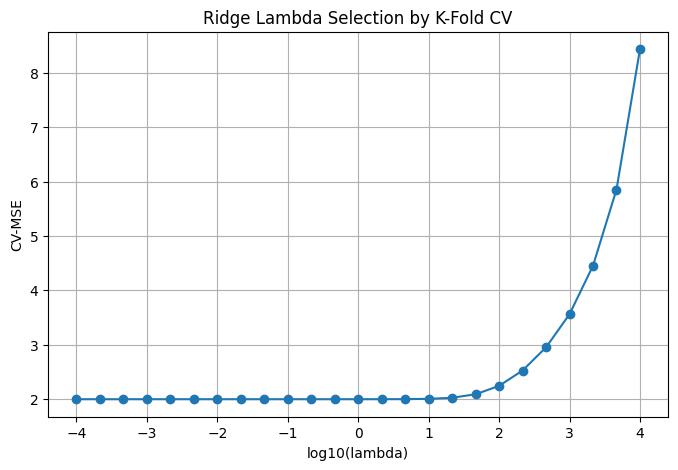

In [2]:
plot_cv_results(cv_results)


### Hệ số Ridge và Ridge Trace

Bảng hệ số Ridge giúp xem biến nào có độ lớn hệ số nổi bật sau khi dữ liệu đã được chuẩn hóa. Ridge Trace cho thấy các hệ số thay đổi như thế nào khi $\lambda$ tăng.


In [3]:
ridge_coefficients_table(ridge_beta, feature_names).head(15)


,Feature,Coefficient
0,intercept,9.996162
3,PT08.S2(NMHC),8.519096
5,PT08.S3(NOx),1.304070
9,T,-0.938671
11,AH,0.858057
2,PT08.S1(CO),0.513505
7,PT08.S4(NO2),-0.436395
10,RH,-0.428592
14,Hour,-0.240767
4,NOx(GT),0.177561


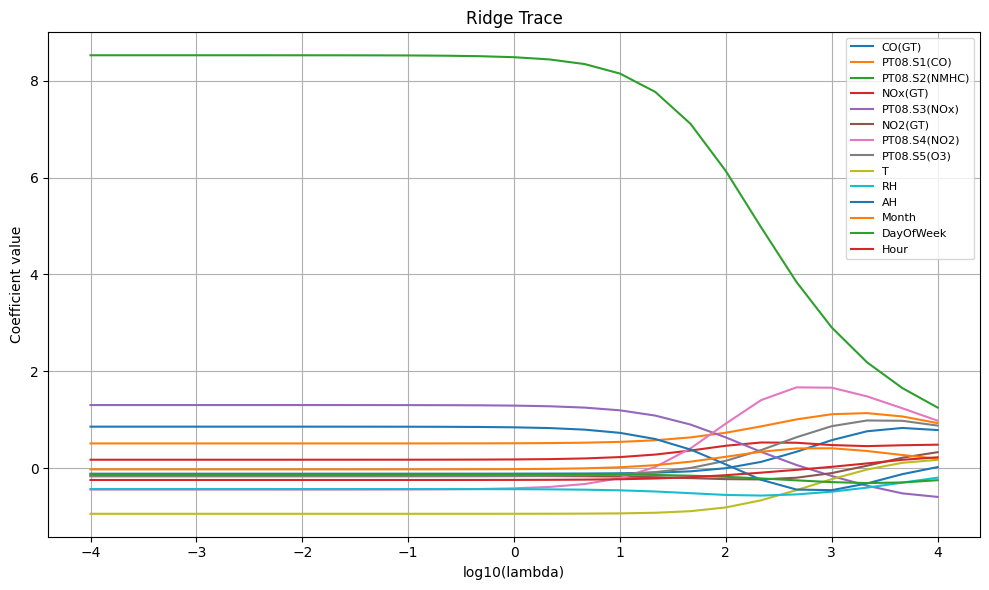

In [4]:
trace_lambdas = cv_results["lambda"].tolist()
_ = plot_ridge_trace(
    data_for_model["X_train"],
    data_for_model["y_train"],
    trace_lambdas,
    feature_names=feature_names,
    max_features=20,
)


Bảng dưới đây là Ridge Trace dạng số: mỗi dòng là một giá trị $\lambda$, mỗi cột là hệ số của một biến. Các hệ số được làm tròn để dễ so sánh xu hướng co hệ số khi $\lambda$ tăng.


In [5]:
ridge_trace_table(
    data_for_model["X_train"],
    data_for_model["y_train"],
    trace_lambdas,
    feature_names=feature_names,
    decimals=4,
    max_features=10,
)


,lambda,log10(lambda),intercept,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH
0,0.0001,-4.0000,9.9962,-0.1113,0.5132,8.5231,0.1770,1.3052,-0.1579,-0.4389,-0.1654,-0.9387,-0.4283
1,0.0002,-3.6667,9.9962,-0.1113,0.5132,8.5231,0.1770,1.3052,-0.1579,-0.4389,-0.1654,-0.9387,-0.4283
2,0.0005,-3.3333,9.9962,-0.1113,0.5132,8.5231,0.1770,1.3052,-0.1579,-0.4389,-0.1654,-0.9387,-0.4283
3,0.0010,-3.0000,9.9962,-0.1113,0.5132,8.5231,0.1770,1.3052,-0.1579,-0.4389,-0.1654,-0.9387,-0.4283
4,0.0022,-2.6667,9.9962,-0.1113,0.5132,8.5231,0.1770,1.3052,-0.1579,-0.4389,-0.1654,-0.9387,-0.4283
5,0.0046,-2.3333,9.9962,-0.1113,0.5132,8.5230,0.1770,1.3052,-0.1579,-0.4388,-0.1654,-0.9387,-0.4283
6,0.0100,-2.0000,9.9962,-0.1113,0.5132,8.5227,0.1770,1.3051,-0.1579,-0.4387,-0.1654,-0.9387,-0.4283
7,0.0215,-1.6667,9.9962,-0.1113,0.5132,8.5223,0.1771,1.3050,-0.1579,-0.4384,-0.1653,-0.9387,-0.4284
8,0.0464,-1.3333,9.9962,-0.1113,0.5133,8.5213,0.1772,1.3047,-0.1580,-0.4378,-0.1652,-0.9387,-0.4284
9,0.1000,-1.0000,9.9962,-0.1112,0.5135,8.5191,0.1776,1.3041,-0.1580,-0.4364,-0.1650,-0.9387,-0.4286


## 5. OLS chọn biến bằng p-value và VIF

OLS chọn biến được thực hiện bằng backward elimination. Ban đầu mô hình sử dụng toàn bộ biến đầu vào, sau đó lặp lại quá trình fit OLS và loại từng biến không phù hợp.

Tiêu chí loại biến:

- **VIF (Variance Inflation Factor):** nếu VIF > 10, biến có đa cộng tuyến mạnh và được ưu tiên loại trước.
- **p-value:** nếu không còn biến nào vượt ngưỡng VIF, biến có p-value > 0.05 sẽ được xét loại.
- **Backward elimination:** mỗi vòng chỉ loại một biến, sau đó fit lại OLS từ đầu trên tập biến còn lại.

Cột intercept luôn được giữ lại và không bị xét loại.


### 5.1. Chi tiết quá trình chọn biến

Bảng dưới đây ghi lại từng bước backward elimination: biến bị loại, lý do loại và giá trị VIF hoặc p-value tương ứng. Phần này cần đặt trước bảng tổng hợp để người đọc thấy mô hình OLS chọn biến đã được tạo ra như thế nào.


In [6]:
import pandas as pd

removal_log = selection_result["removal_log"]

print("Số biến đã loại:", len(selection_result["removed_features"]))
print("Biến đã loại:", selection_result["removed_features"])
print("Biến còn lại:", selection_result["selected_features"])

if removal_log:
    removal_log_df = pd.DataFrame([
        {
            "Bước": item["step"],
            "Biến bị loại": item["feature"],
            "Lý do": item["reason"],
            "VIF/p-value": round(item["value"], 6),
        }
        for item in removal_log
    ])
    display(removal_log_df)
else:
    print("Không có biến nào bị loại trong quá trình OLS chọn biến.")


Số biến đã loại: 2
Biến đã loại: ['PT08.S2(NMHC)', 'T']
Biến còn lại: ['intercept', 'CO(GT)', 'PT08.S1(CO)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'RH', 'AH', 'Month', 'DayOfWeek', 'Hour']


,Bước,Biến bị loại,Lý do,VIF/p-value
0,1,PT08.S2(NMHC),VIF,31.742536
1,2,T,VIF,14.549521


## 6. Bảng tổng hợp MAE, RMSE, $R^2$ của 4 mô hình

Sau khi đã có OLS cơ bản, OLS chọn biến, Ridge với $\lambda$ tốt nhất và Bayesian Linear Regression, bảng dưới đây so sánh cả 4 mô hình trên cùng test set.


In [7]:
metrics_table


,Model,MAE,RMSE,R2
0,OLS,0.889981,1.446089,0.963608
1,OLS (Variable Selection),1.428491,2.072625,0.925242
2,Ridge (lambda=0.1),0.889957,1.446081,0.963608
3,Bayesian Linear Regression,0.889976,1.446087,0.963608


## 7. Phân tích kết quả so sánh 4 mô hình

### Nhận xét theo các chỉ số đánh giá

Bảng kết quả cho thấy OLS cơ bản, Ridge Regression và Bayesian Linear Regression có hiệu suất gần như tương đương nhau trên tập test. OLS đạt MAE = 0.889981, RMSE = 1.446089 và $R^2$ = 0.963608. Ridge với $\lambda = 0.1$ đạt kết quả nhỉnh hơn rất nhỏ, với MAE = 0.889957, RMSE = 1.446081 và $R^2$ = 0.963608. Bayesian Linear Regression cũng gần như trùng với OLS, với MAE = 0.889976, RMSE = 1.446087 và $R^2$ = 0.963608. Mức chênh lệch giữa ba mô hình này rất nhỏ, nên về mặt thực tế có thể xem chúng cho năng lực dự báo tương đương trên bộ dữ liệu này.

OLS chọn biến có hiệu suất thấp hơn rõ rệt: MAE tăng lên 1.428491, RMSE tăng lên 2.072625 và $R^2$ giảm xuống 0.925242. Điều này cho thấy việc loại biến theo VIF và p-value giúp mô hình gọn hơn, dễ diễn giải hơn, nhưng đồng thời làm mất một phần thông tin dự báo quan trọng. Với bài toán dự báo `C6H6(GT)`, mức giảm $R^2$ từ 0.963608 xuống 0.925242 là đáng kể, đặc biệt khi ba mô hình còn lại đều giữ được sai số thấp hơn nhiều.

### Giải thích theo ngữ cảnh dữ liệu

Dataset AirQuality có nhiều biến cảm biến tương quan mạnh với nồng độ Benzene, đặc biệt các tín hiệu như `PT08.S2(NMHC)` và các cảm biến khí khác. Vì quan hệ tuyến tính giữa các cảm biến và target đã khá mạnh, OLS cơ bản đã mô hình hóa tốt dữ liệu. Đây là lý do các mô hình tuyến tính như OLS, Ridge và Bayesian Linear Regression đều đạt $R^2$ cao.

Trong lần chạy hiện tại, OLS chọn biến loại `PT08.S2(NMHC)` và `T`, cả hai đều do VIF cao. VIF cao cho thấy các biến này có quan hệ tuyến tính mạnh với những biến đầu vào khác, tức là có đa cộng tuyến. Tuy nhiên, đa cộng tuyến không đồng nghĩa với việc biến đó không hữu ích cho dự báo. Trường hợp này cho thấy `PT08.S2(NMHC)` vẫn chứa tín hiệu dự báo mạnh cho `C6H6(GT)`, nên khi loại biến này ra khỏi mô hình, sai số test tăng lên rõ rệt.

Ridge Regression xử lý đa cộng tuyến theo hướng co nhỏ hệ số thay vì loại bỏ biến. Vì vậy Ridge vẫn giữ được thông tin từ toàn bộ biến đầu vào, đồng thời giảm ảnh hưởng của các hệ số không ổn định do các biến tương quan mạnh. Đây là lý do Ridge giữ hiệu suất gần như ngang OLS và tốt hơn OLS chọn biến. Trong bảng kết quả, Ridge có MAE và RMSE thấp nhất, nhưng mức cải thiện so với OLS rất nhỏ nên không nên diễn giải là Ridge vượt trội rõ rệt.

Bayesian Linear Regression cho kết quả rất gần OLS vì prior variance = 100 là prior tương đối yếu. Khi prior yếu, posterior mean chủ yếu được quyết định bởi dữ liệu quan sát, nên nghiệm thu được gần với nghiệm OLS. Nếu muốn Bayesian Linear Regression khác biệt rõ hơn, cần thử prior mạnh hơn hoặc khai thác thêm phân phối hậu nghiệm để đánh giá độ bất định của hệ số và dự báo.

Tóm lại, nếu mục tiêu chính là dự báo chính xác `C6H6(GT)`, OLS cơ bản, Ridge và Bayesian Linear Regression đều là các lựa chọn tốt, trong đó Ridge có chỉ số tốt nhất nhưng chỉ hơn OLS ở mức rất nhỏ. Nếu mục tiêu là mô hình gọn và dễ giải thích hơn, OLS chọn biến có lợi thế vì giảm số biến đầu vào, nhưng cần chấp nhận đánh đổi bằng sai số cao hơn và $R^2$ thấp hơn.
